## Breast histopathology image classification —  400X magnification, ResNet50

In [1]:

!unzip /content/Histological_Data-20260712T062756Z-2-001.zip -d /content/

Archive:  /content/Histological_Data-20260712T062756Z-2-001.zip
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-15-190EF-400-004.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-15-190EF-400-011.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-14-19440-400-014.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-15-190EF-400-008.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-15-190EF-400-009.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-14-19440-400-024.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-14-19440-400-028.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-14-19440-400-034.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-14-19440-400-022.png  
  inflating: /content/Histological_Data/Malignant/Copy of SOB_M_PC-14-19440-400-033.png  
  inflating: /content/Histological_D

In [2]:
import os

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
CLASS_NAMES = ['benign', 'malignant']
NUM_CLASSES = len(CLASS_NAMES)

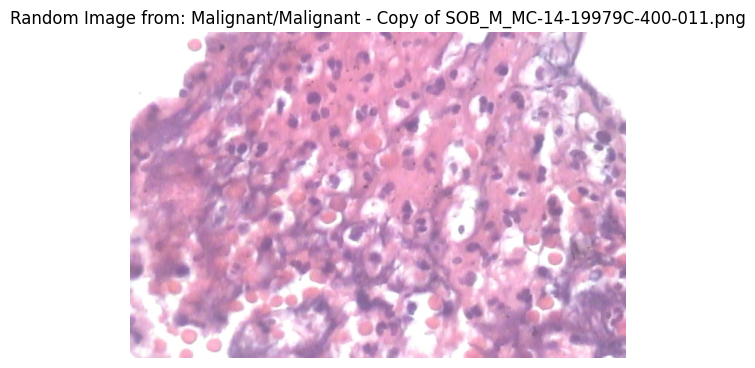

Successfully loaded and displayed: /content/Histological_Data/Malignant/Copy of SOB_M_MC-14-19979C-400-011.png


In [3]:
import os as _os
import random
from PIL import Image
import matplotlib.pyplot as plt

data_base_path = '/content/Histological_Data/'

categories = [d for d in _os.listdir(data_base_path) if _os.path.isdir(_os.path.join(data_base_path, d))]

if not categories:
    print(f"No categories found in {data_base_path}. Please check your unzipping process and paths.")
else:
    random_category = random.choice(categories)
    category_path = _os.path.join(data_base_path, random_category)
    subfolders = [d for d in _os.listdir(category_path) if _os.path.isdir(_os.path.join(category_path, d))]

    if subfolders:

        chosen_path = _os.path.join(category_path, random.choice(subfolders))
    else:

        chosen_path = category_path


    image_files = [f for f in _os.listdir(chosen_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    if not image_files:
        print(f"No image files found in {chosen_path}.")
    else:

        random_image_file = random.choice(image_files)
        image_path = _os.path.join(chosen_path, random_image_file)
        try:
            img = Image.open(image_path)
            plt.imshow(img)
            plt.title(f"Random Image from: {random_category}/{_os.path.basename(chosen_path)} - {random_image_file}")
            plt.axis('off')
            plt.show()
            print(f"Successfully loaded and displayed: {image_path}")
        except Exception as e:
            print(f"Error loading or displaying image {image_path}: {e}")

## 3.1. Creating Train and Validation Directories and Splitting Data

In [6]:
import os as _os
import shutil
import random
import pandas as pd
import hashlib
data_base_path = '/content/Histological_Data/'

def extract_patient_id(filename):
    name = _os.path.splitext(_os.path.basename(filename))[0]
    tokens = name.split('-')
    if len(tokens) > 2:
        return tokens[2]
    return name

kfold_data_dir = _os.path.join(data_base_path, 'kfold_data')
test_dir = _os.path.join(data_base_path, 'test')
kfold_ratio = 0.85
SPLIT_SEED = 42
random.seed(SPLIT_SEED)

already_split = (
    _os.path.exists(kfold_data_dir) and _os.path.exists(test_dir)
    and any(_os.scandir(kfold_data_dir)) and any(_os.scandir(test_dir))
)

if already_split:
    print("kfold_data/ and test/ already exist — skipping re-split to keep")
    print("the test set fixed and reproducible across notebook runs.")
    print(f"  KFOLD_DATA_DIR: {kfold_data_dir}")
    print(f"  TEST_DIR      : {test_dir}")
    print("\nIf you genuinely want to re-split (e.g. new raw data added),")
    print("delete kfold_data/ and test/ manually first, then re-run this cell.")
else:
    for directory in [kfold_data_dir, test_dir]:
        if _os.path.exists(directory):
            print(f"Removing existing directory: {directory}")
            shutil.rmtree(directory)

    normal_data_path = _os.path.join(data_base_path, 'normal')
    if _os.path.exists(normal_data_path):
        print(f"Removing existing normal class directory: {normal_data_path}")
        shutil.rmtree(normal_data_path)
    for directory in [kfold_data_dir, test_dir]:
        _os.makedirs(directory)
        print(f"Created directory: {directory}")

    print("Preparing data for K-fold cross-validation and a separate test set...")
    actual_dirs = {
        d.lower(): d
        for d in _os.listdir(data_base_path)
        if _os.path.isdir(_os.path.join(data_base_path, d))
    }

    for category_name in CLASS_NAMES:
        print(f"Processing category: {category_name}")
        matched_dir = actual_dirs.get(category_name.lower())

        if matched_dir is None:
            print(f"Warning: Original category directory not found for '{category_name}' "
                  f"in {data_base_path} (found: {list(actual_dirs.values())}). Skipping.")
            continue
        original_category_path = _os.path.join(data_base_path, matched_dir)

        kfold_category_path = _os.path.join(kfold_data_dir, category_name)
        test_category_path = _os.path.join(test_dir, category_name)

        for path in [kfold_category_path, test_category_path]:
            if not _os.path.exists(path):
                _os.makedirs(path)
                print(f"Created class subdirectory: {path}")

        all_files = []

        for root, _, files in _os.walk(original_category_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    all_files.append(_os.path.join(root, file))

        all_files.sort()

        num_total_files = len(all_files)
        if num_total_files == 0:
            print(f"No image files found for category {category_name} in {original_category_path}. Skipping split for this category.")
            continue

        patient_to_files = {}
        for f in all_files:
            pid = extract_patient_id(f)
            patient_to_files.setdefault(pid, []).append(f)

        patient_ids = sorted(patient_to_files.keys())
        random.shuffle(patient_ids)

        num_patients = len(patient_ids)
        print(f"  {category_name}: {num_total_files} images from {num_patients} unique patients/slides.")
        if num_patients == num_total_files:
            print(f"  WARNING: every file in '{category_name}' produced a distinct patient ID -- "
                  f"patient grouping had no effect. Check extract_patient_id() against your actual "
                  f"filenames, e.g.: {all_files[:3]}")

        num_kfold_patients = int(num_patients * kfold_ratio)
        kfold_patients = set(patient_ids[:num_kfold_patients])
        test_patients  = set(patient_ids[num_kfold_patients:])

        kfold_files = [f for pid in kfold_patients for f in patient_to_files[pid]]
        test_files  = [f for pid in test_patients  for f in patient_to_files[pid]]

        print(f"Splitting {category_name} data by PATIENT ({num_kfold_patients}/{num_patients} patients -> kfold_data)...")
        for file_path in kfold_files:
            shutil.copy(file_path, _os.path.join(kfold_category_path, _os.path.basename(file_path)))

        for file_path in test_files:
            shutil.copy(file_path, _os.path.join(test_category_path, _os.path.basename(file_path)))

        print(f"Moved {len(kfold_files)} {category_name} images ({len(kfold_patients)} patients) to kfold_data.")
        print(f"  Sample kfold_data files: {[_os.path.basename(f) for f in kfold_files[:5]]}")

        kfold_file_names_str = '\n'.join(sorted([_os.path.basename(f) for f in kfold_files]))
        kfold_hash = hashlib.sha256(kfold_file_names_str.encode()).hexdigest()
        print(f"  Kfold data files hash: {kfold_hash}")

        print(f"Moved {len(test_files)} {category_name} images ({len(test_patients)} patients) to test.")
        print(f"  Sample test files: {[_os.path.basename(f) for f in test_files[:5]]}")

        test_file_names_str = '\n'.join(sorted([_os.path.basename(f) for f in test_files]))
        test_hash = hashlib.sha256(test_file_names_str.encode()).hexdigest()
        print(f"  Test data files hash: {test_hash}")
        overlap = kfold_patients & test_patients
        assert not overlap, f"Patient leakage detected in {category_name}: {overlap}"
        print(f"  ✓ Verified: 0 patients overlap between kfold_data and test for {category_name}.")

    print("Data split complete for K-fold and Test sets!")

KFOLD_DATA_DIR = kfold_data_dir # This will be the source for cross-validation
TEST_DIR = test_dir # This will be used for final model evaluation
TRAIN_DIR = KFOLD_DATA_DIR

print(f"KFOLD_DATA_DIR is now set to: {KFOLD_DATA_DIR}")
print(f"TEST_DIR is now set to: {TEST_DIR}")
print("IMPORTANT: Please re-run the 'Data Loading and Augmentation' cell (4e2da3ac) next. Note that train_generator and validation_generator from that cell will be superseded by the K-fold loop.")

Created directory: /content/Histological_Data/kfold_data
Created directory: /content/Histological_Data/test
Preparing data for K-fold cross-validation and a separate test set...
Processing category: benign
Created class subdirectory: /content/Histological_Data/kfold_data/benign
Created class subdirectory: /content/Histological_Data/test/benign
  benign: 588 images from 24 unique patients/slides.
Splitting benign data by PATIENT (20/24 patients -> kfold_data)...
Moved 482 benign images (20 patients) to kfold_data.
  Sample kfold_data files: ['Copy of SOB_B_A-14-22549AB-400-001.png', 'Copy of SOB_B_A-14-22549AB-400-002.png', 'Copy of SOB_B_A-14-22549AB-400-003.png', 'Copy of SOB_B_A-14-22549AB-400-004.png', 'Copy of SOB_B_A-14-22549AB-400-005.png']
  Kfold data files hash: ccebc973da48ff55747df75a17e2ef57e88e6cd1afe1d21bb20d8b87190e0735
Moved 106 benign images (4 patients) to test.
  Sample test files: ['Copy of SOB_B_TA-14-13200-400-001.png', 'Copy of SOB_B_TA-14-13200-400-002.png', 'Co

In [8]:
import os as _os
import shutil
import random
import pandas as pd
import hashlib
data_base_path = '/content/Histological_Data/'


def extract_patient_id(filename):

    name = _os.path.splitext(_os.path.basename(filename))[0]
    tokens = name.split('-')
    if len(tokens) > 2:
        return tokens[2]
    return name

kfold_data_dir = _os.path.join(data_base_path, 'kfold_data')
test_dir = _os.path.join(data_base_path, 'test')

kfold_ratio = 0.85
SPLIT_SEED = 42
random.seed(SPLIT_SEED)

already_split = (
    _os.path.exists(kfold_data_dir) and _os.path.exists(test_dir)
    and any(_os.scandir(kfold_data_dir)) and any(_os.scandir(test_dir))
)

if already_split:
    print("kfold_data/ and test/ already exist — skipping re-split to keep")
    print("the test set fixed and reproducible across notebook runs.")
    print(f"  KFOLD_DATA_DIR: {kfold_data_dir}")
    print(f"  TEST_DIR      : {test_dir}")
    print("\nIf you genuinely want to re-split (e.g. new raw data added),")
    print("delete kfold_data/ and test/ manually first, then re-run this cell.")
else:

    for directory in [kfold_data_dir, test_dir]:
        if _os.path.exists(directory):
            print(f"Removing existing directory: {directory}")
            shutil.rmtree(directory)

    normal_data_path = _os.path.join(data_base_path, 'normal')
    if _os.path.exists(normal_data_path):
        print(f"Removing existing normal class directory: {normal_data_path}")
        shutil.rmtree(normal_data_path)
    for directory in [kfold_data_dir, test_dir]:
        _os.makedirs(directory)
        print(f"Created directory: {directory}")

    print("Preparing data for K-fold cross-validation and a separate test set...")

    actual_dirs = {
        d.lower(): d
        for d in _os.listdir(data_base_path)
        if _os.path.isdir(_os.path.join(data_base_path, d))
    }

    for category_name in CLASS_NAMES:
        print(f"Processing category: {category_name}")
        matched_dir = actual_dirs.get(category_name.lower())

        if matched_dir is None:
            print(f"Warning: Original category directory not found for '{category_name}' "
                  f"in {data_base_path} (found: {list(actual_dirs.values())}). Skipping.")
            continue
        original_category_path = _os.path.join(data_base_path, matched_dir)

        kfold_category_path = _os.path.join(kfold_data_dir, category_name)
        test_category_path = _os.path.join(test_dir, category_name)

        for path in [kfold_category_path, test_category_path]:
            if not _os.path.exists(path):
                _os.makedirs(path)
                print(f"Created class subdirectory: {path}")

        all_files = []

        for root, _, files in _os.walk(original_category_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    all_files.append(_os.path.join(root, file))

        all_files.sort()

        num_total_files = len(all_files)
        if num_total_files == 0:
            print(f"No image files found for category {category_name} in {original_category_path}. Skipping split for this category.")
            continue

        patient_to_files = {}
        for f in all_files:
            pid = extract_patient_id(f)
            patient_to_files.setdefault(pid, []).append(f)

        patient_ids = sorted(patient_to_files.keys())
        random.shuffle(patient_ids)

        num_patients = len(patient_ids)
        print(f"  {category_name}: {num_total_files} images from {num_patients} unique patients/slides.")
        if num_patients == num_total_files:
            print(f"  WARNING: every file in '{category_name}' produced a distinct patient ID -- "
                  f"patient grouping had no effect. Check extract_patient_id() against your actual "
                  f"filenames, e.g.: {all_files[:3]}")

        num_kfold_patients = int(num_patients * kfold_ratio)
        kfold_patients = set(patient_ids[:num_kfold_patients])
        test_patients  = set(patient_ids[num_kfold_patients:])

        kfold_files = [f for pid in kfold_patients for f in patient_to_files[pid]]
        test_files  = [f for pid in test_patients  for f in patient_to_files[pid]]

        print(f"Splitting {category_name} data by PATIENT ({num_kfold_patients}/{num_patients} patients -> kfold_data)...")
        for file_path in kfold_files:
            shutil.copy(file_path, _os.path.join(kfold_category_path, _os.path.basename(file_path)))

        for file_path in test_files:
            shutil.copy(file_path, _os.path.join(test_category_path, _os.path.basename(file_path)))

        print(f"Moved {len(kfold_files)} {category_name} images ({len(kfold_patients)} patients) to kfold_data.")
        print(f"  Sample kfold_data files: {[_os.path.basename(f) for f in kfold_files[:5]]}")

        kfold_file_names_str = '\n'.join(sorted([_os.path.basename(f) for f in kfold_files]))
        kfold_hash = hashlib.sha256(kfold_file_names_str.encode()).hexdigest()
        print(f"  Kfold data files hash: {kfold_hash}")

        print(f"Moved {len(test_files)} {category_name} images ({len(test_patients)} patients) to test.")
        print(f"  Sample test files: {[_os.path.basename(f) for f in test_files[:5]]}")

        test_file_names_str = '\n'.join(sorted([_os.path.basename(f) for f in test_files]))
        test_hash = hashlib.sha256(test_file_names_str.encode()).hexdigest()
        print(f"  Test data files hash: {test_hash}")

        overlap = kfold_patients & test_patients
        assert not overlap, f"Patient leakage detected in {category_name}: {overlap}"
        print(f"  ✓ Verified: 0 patients overlap between kfold_data and test for {category_name}.")

    print("Data split complete for K-fold and Test sets!")

KFOLD_DATA_DIR = kfold_data_dir # This will be the source for cross-validation
TEST_DIR = test_dir # This will be used for final model evaluation
TRAIN_DIR = KFOLD_DATA_DIR

print(f"KFOLD_DATA_DIR is now set to: {KFOLD_DATA_DIR}")
print(f"TEST_DIR is now set to: {TEST_DIR}")

kfold_data/ and test/ already exist — skipping re-split to keep
the test set fixed and reproducible across notebook runs.
  KFOLD_DATA_DIR: /content/Histological_Data/kfold_data
  TEST_DIR      : /content/Histological_Data/test

If you genuinely want to re-split (e.g. new raw data added),
delete kfold_data/ and test/ manually first, then re-run this cell.
KFOLD_DATA_DIR is now set to: /content/Histological_Data/kfold_data
TEST_DIR is now set to: /content/Histological_Data/test


In [9]:
from sklearn.model_selection import StratifiedGroupKFold
NFOLDS = 5
kf = StratifiedGroupKFold(n_splits=NFOLDS, shuffle=True, random_state=42)

print(f"StratifiedGroupKFold initialized with {NFOLDS} splits (grouped by patient, no leakage).")


StratifiedGroupKFold initialized with 5 splits (grouped by patient, no leakage).


## 1.5 Stain Normalization (Macenko)


Macenko normalizer fitted: True  (reference: /content/Histological_Data/kfold_data/benign/Copy of SOB_B_A-14-22549AB-400-001.png)


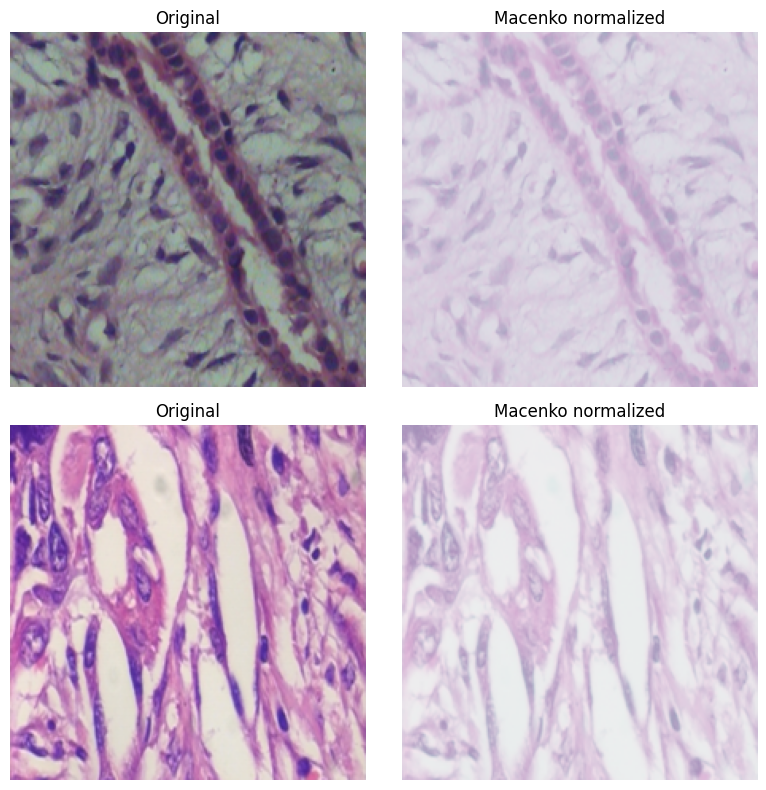

In [10]:
import os as _os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image

class MacenkoNormalizer:
    """
    NumPy implementation of Macenko et al. (2009) stain normalization.
    fit() learns a reference stain matrix + max concentrations from one
    representative H&E image. transform() re-stains any other image to
    match that reference's color appearance while preserving its own
    tissue structure (shape/texture untouched, only color remapped).
    Falls back to returning the input image unchanged if the SVD/percentile
    computation degenerates (e.g. a near-blank / background-only patch).
    """
    def __init__(self, Io=240, alpha=1, beta=0.15):
        self.Io = Io          # transmitted light intensity (background)
        self.alpha = alpha    # percentile cutoff for stain-vector angle
        self.beta = beta      # OD threshold for background/transparent pixels
        self.HERef = np.array([[0.5626, 0.2159],
                                [0.7201, 0.8012],
                                [0.4062, 0.5581]])
        self.maxCRef = np.array([1.9705, 1.0308])
        self.fitted = False

    def _stain_matrix_and_od(self, img):
        px = img.reshape((-1, 3)).astype(np.float64)
        OD = -np.log10((px + 1) / self.Io)
        ODhat = OD[~np.any(OD < self.beta, axis=1)]
        if ODhat.shape[0] < 10:
            return None, None
        eigvals, eigvecs = np.linalg.eigh(np.cov(ODhat.T))
        top2 = eigvecs[:, [-2, -1]]                      # OD plane
        That = ODhat.dot(top2)
        phi = np.arctan2(That[:, 1], That[:, 0])
        minPhi = np.percentile(phi, self.alpha)
        maxPhi = np.percentile(phi, 100 - self.alpha)
        vMin = top2.dot(np.array([np.cos(minPhi), np.sin(minPhi)]))
        vMax = top2.dot(np.array([np.cos(maxPhi), np.sin(maxPhi)]))
        HE = np.array([vMin, vMax]).T if vMin[0] > vMax[0] else np.array([vMax, vMin]).T
        norms = np.linalg.norm(HE, axis=0)
        norms[norms == 0] = 1e-6
        return HE / norms, OD

    def fit(self, target_img):
        HE, OD = self._stain_matrix_and_od(target_img)
        if HE is None:
            self.fitted = False
            return self
        C = np.linalg.lstsq(HE, OD.T, rcond=None)[0]
        self.HERef = HE
        self.maxCRef = np.percentile(C, 99, axis=1)
        self.fitted = True
        return self

    def transform(self, img):
        try:
            h, w, c = img.shape
            HE, OD = self._stain_matrix_and_od(img)
            if HE is None:
                return img
            C = np.linalg.lstsq(HE, OD.T, rcond=None)[0]
            maxC = np.percentile(C, 99, axis=1)
            maxC[maxC == 0] = 1e-6
            C = C * (self.maxCRef / maxC)[:, None]
            Inorm = self.Io * np.exp(-self.HERef.dot(C))
            Inorm = np.clip(Inorm, 0, 255).T.reshape(h, w, c).astype(np.uint8)
            return Inorm
        except Exception:
            return img


def make_combined_preprocess(normalizer):
    """Stain-normalize, then apply the standard ResNet50 ImageNet preprocessing.
    Used as the `preprocessing_function` for every ImageDataGenerator below."""
    def _fn(img):
        img_uint8 = np.clip(img, 0, 255).astype(np.uint8)
        normalized = normalizer.transform(img_uint8) if normalizer.fitted else img_uint8
        return preprocess_input(normalized.astype(np.float32))
    return _fn

_ref_candidates = sorted(_os.listdir(_os.path.join(KFOLD_DATA_DIR, 'benign')))
_ref_path = _os.path.join(KFOLD_DATA_DIR, 'benign', _ref_candidates[0])
_ref_img = np.array(Image.open(_ref_path).convert('RGB').resize((IMG_WIDTH, IMG_HEIGHT)))

macenko_normalizer = MacenkoNormalizer().fit(_ref_img)
combined_preprocess = make_combined_preprocess(macenko_normalizer)
print(f"Macenko normalizer fitted: {macenko_normalizer.fitted}  (reference: {_ref_path})")

_sample_files = [
    _os.path.join(KFOLD_DATA_DIR, 'benign', _ref_candidates[len(_ref_candidates)//2]),
    _os.path.join(KFOLD_DATA_DIR, 'malignant',
                   sorted(_os.listdir(_os.path.join(KFOLD_DATA_DIR, 'malignant')))[0]),
]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for row, p in enumerate(_sample_files):
    orig = np.array(Image.open(p).convert('RGB').resize((IMG_WIDTH, IMG_HEIGHT)))
    norm = macenko_normalizer.transform(orig)
    axes[row, 0].imshow(orig); axes[row, 0].set_title('Original'); axes[row, 0].axis('off')
    axes[row, 1].imshow(norm); axes[row, 1].set_title('Macenko normalized'); axes[row, 1].axis('off')
plt.tight_layout()
plt.show()


## 2. Setup ResNet-50 Model with Custom Classification Head



In [11]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

NUM_CLASSES = 2
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

def build_model(l2_reg=1e-4, label_smoothing=0.05):

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    for layer in base_model.layers[143:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    x = Dense(256, activation='relu', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

test_model = build_model()
trainable = sum(1 for l in test_model.layers if l.trainable)
total     = len(test_model.layers)
print(f"Trainable layers: {trainable}/{total}")
print(f"Output shape: {test_model.output_shape}")
del test_model

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Trainable layers: 27/180
Output shape: (None, 1)


### 2.5 Sanity Check: Overfit a Tiny Batch (Memorization Test)



In [12]:
import numpy as np, os as _os, tensorflow as tf
from PIL import Image

N_PER_CLASS = 8
sanity_paths, sanity_labels = [], []
for label_idx, cls in enumerate(CLASS_NAMES):
    cls_dir = _os.path.join(KFOLD_DATA_DIR, cls)
    for fname in sorted(_os.listdir(cls_dir))[:N_PER_CLASS]:
        sanity_paths.append(_os.path.join(cls_dir, fname))
        sanity_labels.append(label_idx)

X_sanity = np.stack([
    combined_preprocess(
        np.array(Image.open(p).convert('RGB').resize((IMG_WIDTH, IMG_HEIGHT))).astype(np.float32)
    )
    for p in sanity_paths
])
y_sanity = np.array(sanity_labels, dtype=np.float32)
print(f"Sanity-check batch: {len(X_sanity)} images ({N_PER_CLASS} per class)")

sanity_model = build_model(l2_reg=0.0, label_smoothing=0.0)
sanity_history = sanity_model.fit(
    X_sanity, y_sanity,
    batch_size=len(X_sanity),
    epochs=50,
    verbose=0
)

final_loss = sanity_history.history['loss'][-1]
final_acc  = sanity_history.history['accuracy'][-1]
print(f"\nAfter 50 epochs on {len(X_sanity)} fixed images:")
print(f"  Train loss     : {final_loss:.4f}  (should be close to 0)")
print(f"  Train accuracy : {final_acc:.4f}  (should be 1.0)")

if final_loss < 0.05 and final_acc >= 0.99:
    print("\n PASS -- model can memorize a tiny batch. Data, labels, "
          "preprocessing, architecture, and loss are wired correctly.")
else:
    print("\n FAIL -- model could not drive loss to ~0 on a tiny, fixed batch. "
          "This points to a bug (mismatched labels, broken preprocessing, frozen "
          "weights, learning rate too low, etc.) -- investigate before running the "
          "full K-fold training below.")

del sanity_model
tf.keras.backend.clear_session()


Sanity-check batch: 16 images (8 per class)

After 50 epochs on 16 fixed images:
  Train loss     : 0.0001  (should be close to 0)
  Train accuracy : 1.0000  (should be 1.0)

✅ PASS -- model can memorize a tiny batch. Data, labels, preprocessing, architecture, and loss are wired correctly.


## 3. Data Loading and Augmentation


In [13]:
from tensorflow.keras.applications.resnet50 import preprocess_input

TRAIN_DIR = '/content/Histological_Data/kfold_data'
VAL_DIR   = '/content/Histological_Data/test'
TEST_DIR  = '/content/Histological_Data/test'

train_datagen = ImageDataGenerator(
    preprocessing_function=combined_preprocess,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    channel_shift_range=20.0,
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(preprocessing_function=combined_preprocess)
test_datagen = ImageDataGenerator(preprocessing_function=combined_preprocess)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASS_NAMES
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASS_NAMES
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    classes=CLASS_NAMES
)

print('Class indices:', train_generator.class_indices)

Found 1555 images belonging to 2 classes.
Found 276 images belonging to 2 classes.
Found 276 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


## 4. K-Fold Cross-Validation Training

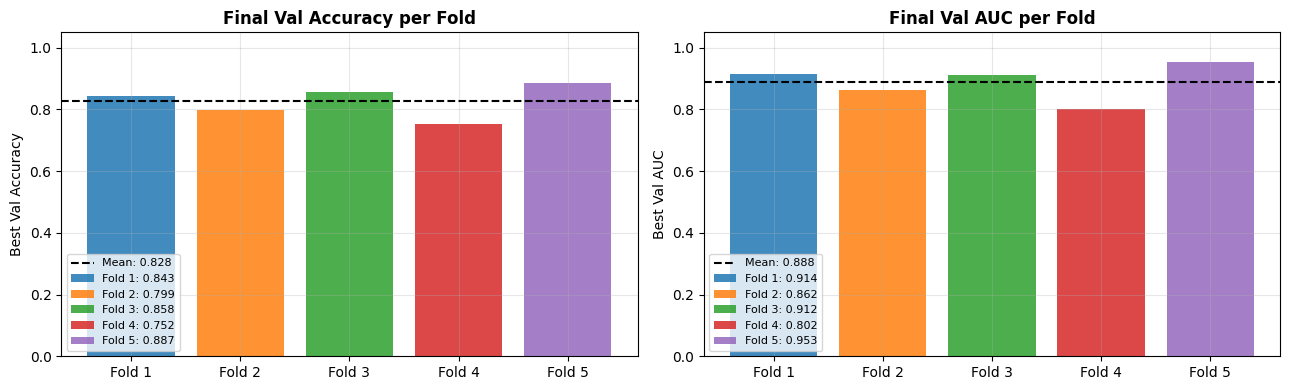


K-fold training complete.
 fold  val_acc  val_auc
    1 0.842857 0.913560
    2 0.799427 0.861996
    3 0.857627 0.911654
    4 0.751799 0.802286
    5 0.886926 0.952996

Mean val Accuracy : 0.8277 ± 0.0529
Mean val AUC      : 0.8885 ± 0.0580

Collected 1555 out-of-fold predictions across all 5 folds.
Saved 5 per-fold models for ensembling: ['/content/fold_1_model.keras', '/content/fold_2_model.keras', '/content/fold_3_model.keras', '/content/fold_4_model.keras', '/content/fold_5_model.keras']


In [14]:
import os as _os, numpy as np, tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE  = 32
NFOLDS      = 5
EPOCHS      = 30
CLASS_NAMES = ['benign', 'malignant']

KFOLD_DATA_DIR = '/content/Histological_Data/kfold_data'
TEST_DIR       = '/content/Histological_Data/test'

def extract_patient_id(filename):

    name = _os.path.splitext(_os.path.basename(filename))[0]
    tokens = name.split('-')
    if len(tokens) > 2:
        return tokens[2]
    return name

all_paths, all_labels, all_patient_ids = [], [], []
for label_idx, cls in enumerate(CLASS_NAMES):
    cls_dir = _os.path.join(KFOLD_DATA_DIR, cls)
    for fname in _os.listdir(cls_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            all_paths.append(_os.path.join(cls_dir, fname))
            all_labels.append(label_idx)
            all_patient_ids.append(extract_patient_id(fname))

all_paths       = np.array(all_paths)
all_labels      = np.array(all_labels)
all_patient_ids = np.array(all_patient_ids)
print(f"Total K-fold images: {len(all_paths)}")
print(f"  benign: {(all_labels==0).sum()}  |  malignant: {(all_labels==1).sum()}")
print(f"  unique patients/slides in kfold pool: {len(set(all_patient_ids))}")

def make_generators(train_paths, train_labels, val_paths, val_labels):
    train_df = pd.DataFrame({'filename': train_paths,
                              'class':    [CLASS_NAMES[l] for l in train_labels]})
    val_df   = pd.DataFrame({'filename': val_paths,
                              'class':    [CLASS_NAMES[l] for l in val_labels]})

    train_gen = ImageDataGenerator(
        preprocessing_function=combined_preprocess,   # Macenko + ResNet50 preprocessing
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        channel_shift_range=20.0,
        fill_mode='nearest'
    ).flow_from_dataframe(
        train_df, x_col='filename', y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASS_NAMES,
        shuffle=True
    )
    val_gen = ImageDataGenerator(
        preprocessing_function=combined_preprocess   # Macenko + ResNet50 preprocessing
    ).flow_from_dataframe(
        val_df, x_col='filename', y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASS_NAMES,
        shuffle=False
    )
    return train_gen, val_gen

class LiveCVDashboard(Callback):
    """
    After every epoch, redraws a 2-panel live dashboard:
      Left  — val accuracy curve for the current fold (epoch by epoch)
      Right — best val accuracy bar so far across completed + current fold
    """
    def __init__(self, fold_idx, nfolds, fold_val_metrics):
        super().__init__()
        self.fold_idx        = fold_idx
        self.nfolds          = nfolds
        self.fold_val_metrics = fold_val_metrics   # shared list, grows each fold
        self.epoch_accs      = []   # val_accuracy for current fold, per epoch
        self.epoch_aucs      = []   # val_auc for current fold, per epoch

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.epoch_accs.append(logs.get('val_accuracy', 0))
        self.epoch_aucs.append(logs.get('val_auc', 0))

        clear_output(wait=True)

        fig = plt.figure(figsize=(16, 5))
        gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

        colors = plt.cm.tab10.colors

        ax1 = fig.add_subplot(gs[0])
        ax1.plot(range(1, len(self.epoch_accs) + 1), self.epoch_accs,
                 color=colors[self.fold_idx], lw=2,
                 label=f'Fold {self.fold_idx+1} val acc')
        ax1.axhline(max(self.epoch_accs), color=colors[self.fold_idx],
                    linestyle='--', alpha=0.5,
                    label=f'Best so far: {max(self.epoch_accs):.3f}')
        ax1.set_title(f'Fold {self.fold_idx+1}/{self.nfolds} — Val Accuracy per Epoch',
                      fontweight='bold')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Accuracy')
        ax1.set_ylim(0, 1); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

        ax2 = fig.add_subplot(gs[1])
        ax2.plot(range(1, len(self.epoch_aucs) + 1), self.epoch_aucs,
                 color=colors[self.fold_idx], lw=2,
                 label=f'Fold {self.fold_idx+1} val AUC')
        ax2.axhline(max(self.epoch_aucs), color=colors[self.fold_idx],
                    linestyle='--', alpha=0.5,
                    label=f'Best so far: {max(self.epoch_aucs):.3f}')
        ax2.set_title(f'Fold {self.fold_idx+1}/{self.nfolds} — Val AUC per Epoch',
                      fontweight='bold')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val AUC')
        ax2.set_ylim(0, 1); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

        ax3 = fig.add_subplot(gs[2])

        completed_labels = [f"Fold {m['fold']}" for m in self.fold_val_metrics]
        completed_accs   = [m['val_acc'] for m in self.fold_val_metrics]
        completed_cols   = [colors[m['fold']-1] for m in self.fold_val_metrics]

        current_label = f"Fold {self.fold_idx+1}\n(live)"
        current_acc   = max(self.epoch_accs)

        all_labels_bar = completed_labels + [current_label]
        all_accs_bar   = completed_accs   + [current_acc]
        all_cols_bar   = completed_cols   + [colors[self.fold_idx]]

        x_pos = range(len(all_labels_bar))
        bars = ax3.bar(x_pos, all_accs_bar, color=all_cols_bar, alpha=0.85, width=0.6)
        ax3.set_xticks(x_pos)
        ax3.set_xticklabels(all_labels_bar, fontsize=9)
        ax3.set_ylim(0, 1.05)
        ax3.set_ylabel('Best Val Accuracy')
        ax3.set_title('Accuracy Progress Across Folds', fontweight='bold')
        ax3.grid(axis='y', alpha=0.3)
        if completed_accs:
            ax3.axhline(np.mean(completed_accs + [current_acc]),
                        color='black', linestyle=':', lw=1.5,
                        label=f'Running mean: {np.mean(completed_accs + [current_acc]):.3f}')
            ax3.legend(fontsize=9)
        for bar, acc in zip(bars, all_accs_bar):
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

        fig.suptitle(
            f'K-Fold CV Live Dashboard  |  Epoch {epoch+1}  |  '
            f'Folds done: {len(self.fold_val_metrics)}/{self.nfolds}',
            fontsize=13, fontweight='bold'
        )
        plt.savefig('/content/cv_live_dashboard.png', dpi=120, bbox_inches='tight')
        plt.show()

skf = StratifiedGroupKFold(n_splits=NFOLDS, shuffle=True, random_state=42)

fold_histories   = []
fold_val_metrics = []

oof_probs        = []
oof_labels       = []
oof_patient_ids  = []
fold_model_paths = []

best_val_auc    = -1
best_model_path = '/content/best_resnet50_fold.keras'

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels, groups=all_patient_ids)):
    train_patients = set(all_patient_ids[train_idx])
    val_patients   = set(all_patient_ids[val_idx])
    fold_overlap   = train_patients & val_patients
    assert not fold_overlap, f"Fold {fold_idx+1}: patient leakage between train/val: {fold_overlap}"

    print(f"\n{'='*60}")
    print(f"  FOLD {fold_idx+1} / {NFOLDS}  —  Train: {len(train_idx)} imgs / {len(train_patients)} patients"
          f"  |  Val: {len(val_idx)} imgs / {len(val_patients)} patients")
    print(f"  ✓ No patient overlap between train and val in this fold.")
    print(f"{'='*60}")

    train_gen, val_gen = make_generators(
        all_paths[train_idx], all_labels[train_idx],
        all_paths[val_idx],   all_labels[val_idx]
    )

    fold_train_labels = all_labels[train_idx]
    cw = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(fold_train_labels),
        y=fold_train_labels
    )
    class_weight_dict = {int(c): w for c, w in zip(np.unique(fold_train_labels), cw)}
    print(f"  Class weights (this fold): {class_weight_dict}")

    model = build_model()

    dashboard = LiveCVDashboard(fold_idx, NFOLDS, fold_val_metrics)

    callbacks = [
        EarlyStopping(monitor='val_auc', patience=7,
                      restore_best_weights=True, mode='max', verbose=1),

        dashboard,
    ]

    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks,
        class_weight=class_weight_dict,  # balances training loss only
        verbose=0   # dashboard replaces verbose output
    )

    fold_histories.append(history.history)

    val_auc = max(history.history.get('val_auc', [0]))
    val_acc = max(history.history.get('val_accuracy', [0]))
    fold_val_metrics.append({'fold': fold_idx+1, 'val_acc': val_acc, 'val_auc': val_auc})
    print(f"  Fold {fold_idx+1} best → val AUC: {val_auc:.4f}  |  val Acc: {val_acc:.4f}")

    fold_model_path = f'/content/fold_{fold_idx+1}_model.keras'
    model.save(fold_model_path)
    fold_model_paths.append(fold_model_path)

    val_probs_fold = model.predict(val_gen, verbose=0).ravel()
    oof_probs.extend(val_probs_fold.tolist())
    oof_labels.extend(all_labels[val_idx].tolist())
    oof_patient_ids.extend(all_patient_ids[val_idx].tolist())

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        model.save(best_model_path)
        print(f"  ✓ New best model saved (val_auc={val_auc:.4f})")

    tf.keras.backend.clear_session()

clear_output(wait=True)
metrics_df = pd.DataFrame(fold_val_metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = plt.cm.tab10.colors

# Final accuracy per fold
for i, m in enumerate(fold_val_metrics):
    axes[0].bar(i, m['val_acc'], color=colors[i], alpha=0.85, label=f"Fold {m['fold']}: {m['val_acc']:.3f}")
axes[0].axhline(metrics_df['val_acc'].mean(), color='black', linestyle='--', lw=1.5,
                label=f"Mean: {metrics_df['val_acc'].mean():.3f}")
axes[0].set_xticks(range(NFOLDS))
axes[0].set_xticklabels([f"Fold {m['fold']}" for m in fold_val_metrics])
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Best Val Accuracy')
axes[0].set_title('Final Val Accuracy per Fold', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Final AUC per fold
for i, m in enumerate(fold_val_metrics):
    axes[1].bar(i, m['val_auc'], color=colors[i], alpha=0.85, label=f"Fold {m['fold']}: {m['val_auc']:.3f}")
axes[1].axhline(metrics_df['val_auc'].mean(), color='black', linestyle='--', lw=1.5,
                label=f"Mean: {metrics_df['val_auc'].mean():.3f}")
axes[1].set_xticks(range(NFOLDS))
axes[1].set_xticklabels([f"Fold {m['fold']}" for m in fold_val_metrics])
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('Best Val AUC')
axes[1].set_title('Final Val AUC per Fold', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/kfold_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nK-fold training complete.")
print(metrics_df.to_string(index=False))
print(f"\nMean val Accuracy : {metrics_df['val_acc'].mean():.4f} \u00b1 {metrics_df['val_acc'].std():.4f}")
print(f"Mean val AUC      : {metrics_df['val_auc'].mean():.4f} \u00b1 {metrics_df['val_auc'].std():.4f}")

oof_probs       = np.array(oof_probs)
oof_labels      = np.array(oof_labels)
oof_patient_ids = np.array(oof_patient_ids)
print(f"\nCollected {len(oof_probs)} out-of-fold predictions across all {NFOLDS} folds.")
print(f"Saved {len(fold_model_paths)} per-fold models for ensembling: {fold_model_paths}")


## 5. Training Curves

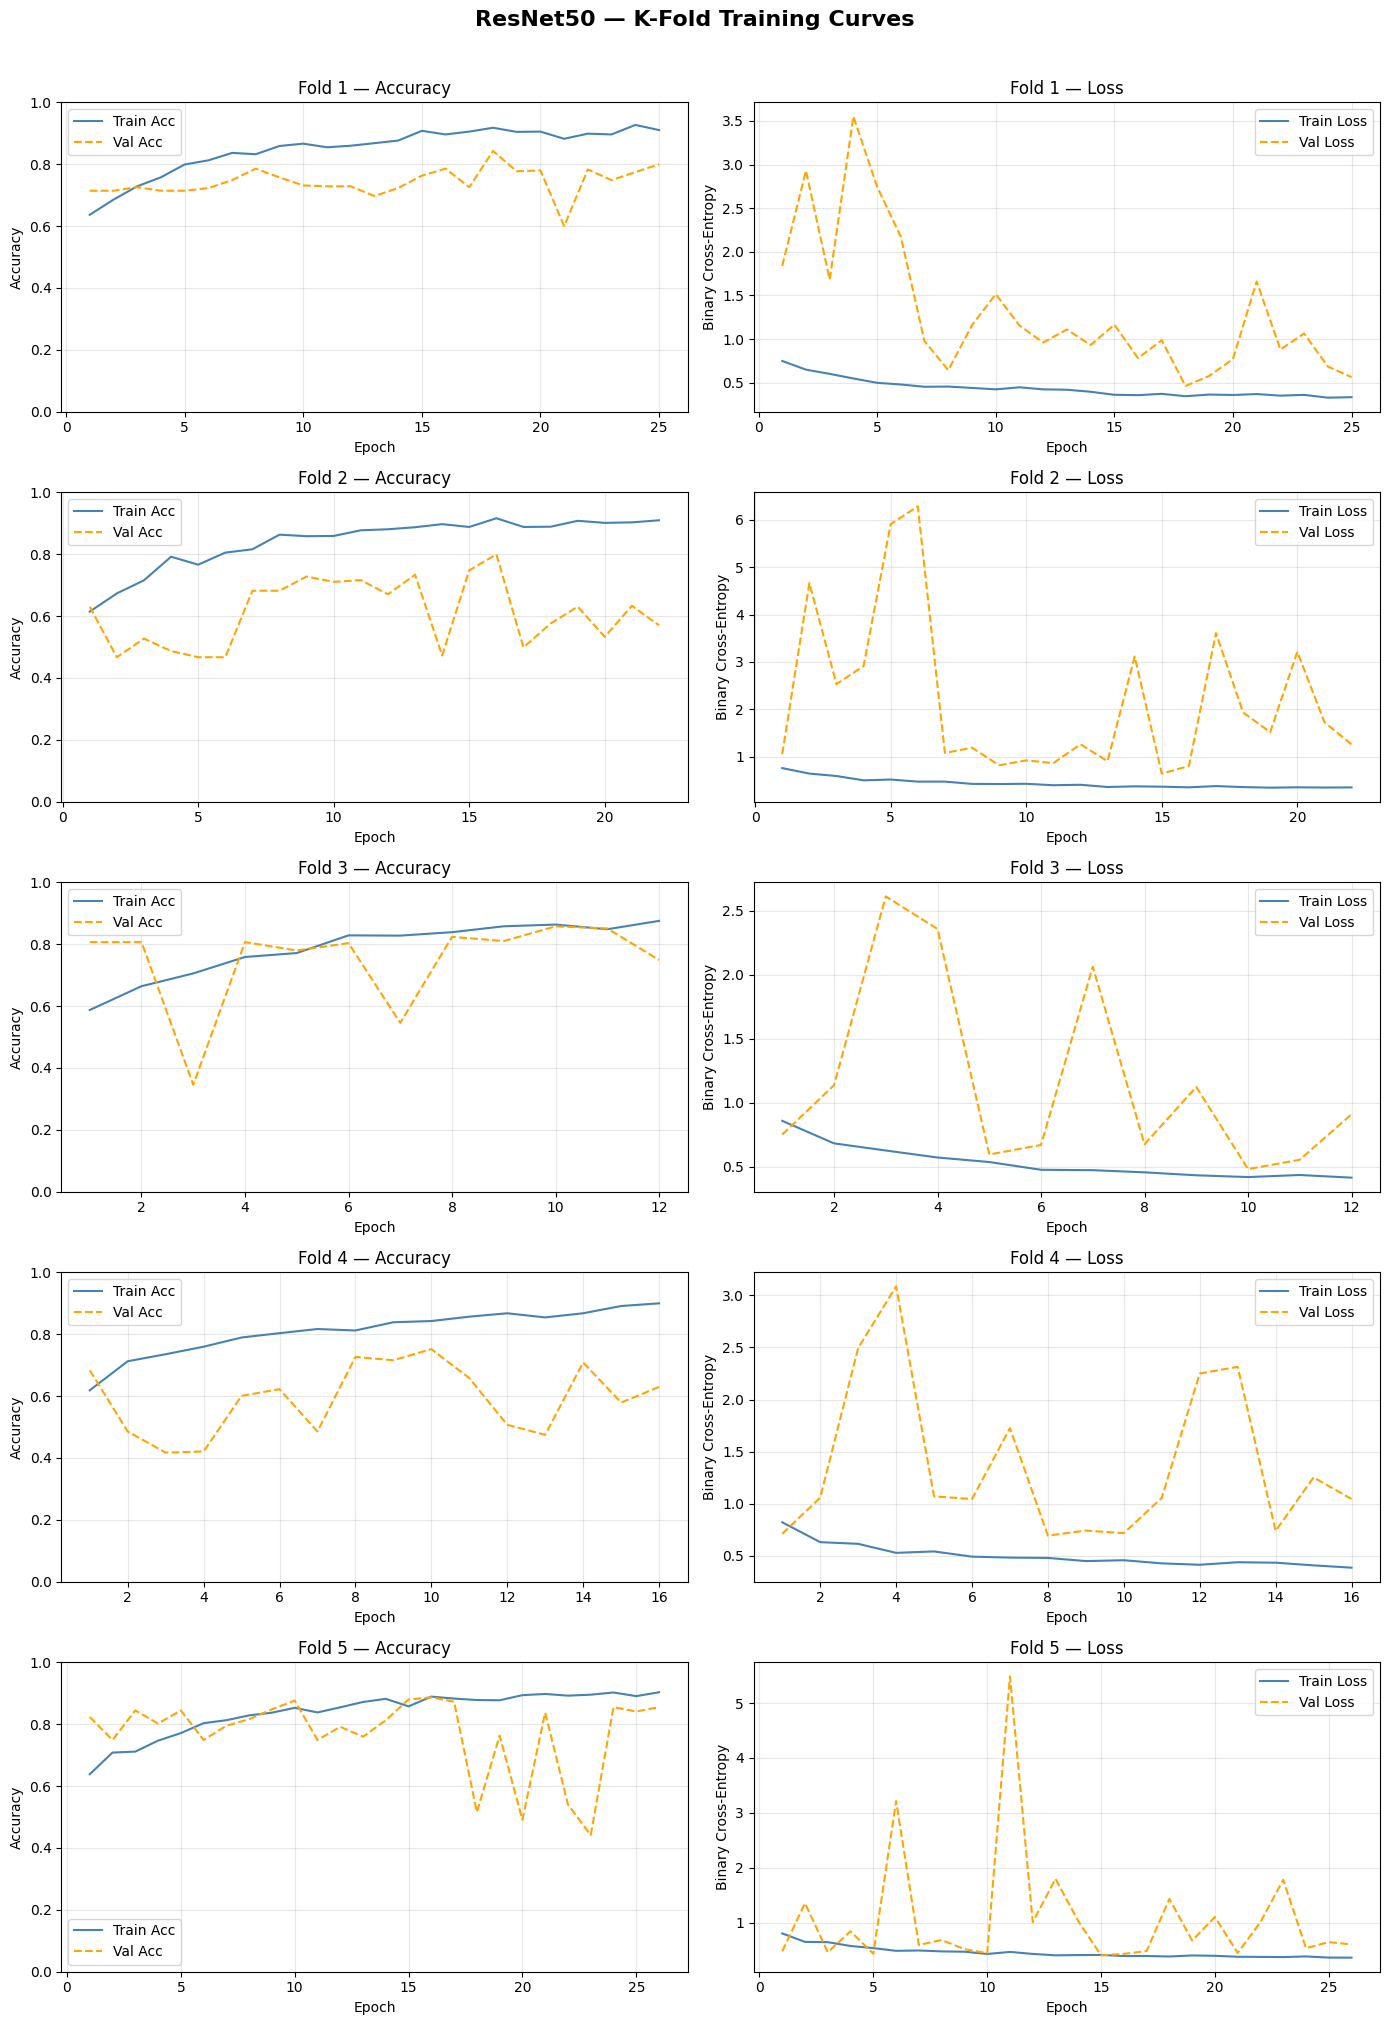

Saved: /content/training_curves.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(NFOLDS, 2, figsize=(14, 4 * NFOLDS))
fig.suptitle('ResNet50 — K-Fold Training Curves', fontsize=16, fontweight='bold', y=1.01)

for fold_idx, h in enumerate(fold_histories):
    epochs_ran = range(1, len(h['accuracy']) + 1)

    ax = axes[fold_idx, 0]
    ax.plot(epochs_ran, h['accuracy'],     label='Train Acc',  color='steelblue')
    ax.plot(epochs_ran, h['val_accuracy'], label='Val Acc',    color='orange', linestyle='--')
    ax.set_title(f'Fold {fold_idx+1} — Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[fold_idx, 1]
    ax.plot(epochs_ran, h['loss'],     label='Train Loss', color='steelblue')
    ax.plot(epochs_ran, h['val_loss'], label='Val Loss',   color='orange', linestyle='--')
    ax.set_title(f'Fold {fold_idx+1} — Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/training_curves.png")


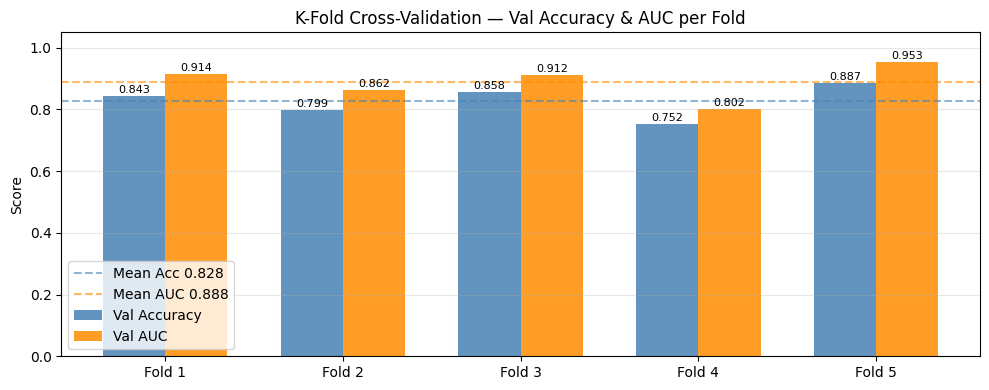

Saved: /content/kfold_summary.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4))
folds = [m['fold'] for m in fold_val_metrics]
accs  = [m['val_acc'] for m in fold_val_metrics]
aucs  = [m['val_auc'] for m in fold_val_metrics]
x = np.arange(len(folds))
width = 0.35

bars1 = ax.bar(x - width/2, accs, width, label='Val Accuracy', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, aucs, width, label='Val AUC',      color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f}' for f in folds])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('K-Fold Cross-Validation — Val Accuracy & AUC per Fold')
ax.axhline(np.mean(accs), color='steelblue',  linestyle='--', alpha=0.6, label=f'Mean Acc {np.mean(accs):.3f}')
ax.axhline(np.mean(aucs), color='darkorange', linestyle='--', alpha=0.6, label=f'Mean AUC {np.mean(aucs):.3f}')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/kfold_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/kfold_summary.png")


## 6. Retrain on Full K-Fold Data



In [20]:
import os, numpy as np, tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

full_df = pd.DataFrame({
    'filename': all_paths,
    'class':    [CLASS_NAMES[l] for l in all_labels]
})

print(f"Retraining on ALL {len(full_df)} k-fold images (no validation split).")
print(f"  benign: {(all_labels==0).sum()}  |  malignant: {(all_labels==1).sum()}")

cw_final = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict_final = {int(c): w for c, w in zip(np.unique(all_labels), cw_final)}
print(f"Class weights (full retrain): {class_weight_dict_final}")

mean_epochs_run = int(np.mean([len(h['loss']) for h in fold_histories]))

FINAL_EPOCHS = 30  #max(mean_epochs_run + 5, 20)
print(f"\nMean epochs run across folds: {mean_epochs_run}")
print(f"Training final model for up to {FINAL_EPOCHS} epochs (no val split; will stop early if training loss plateaus).")

full_train_gen = ImageDataGenerator(
    preprocessing_function=combined_preprocess,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    channel_shift_range=20.0,
    fill_mode='nearest'
).flow_from_dataframe(
    full_df, x_col='filename', y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASS_NAMES,
    shuffle=True
)

final_model = build_model()
callbacks_final = [

    EarlyStopping(monitor='loss', patience=6, restore_best_weights=True,
                  mode='min', verbose=1),
]

final_history = final_model.fit(
    full_train_gen,
    epochs=20, #FINAL_EPOCHS,
    callbacks=callbacks_final,
    class_weight=class_weight_dict_final,  # balances training loss only
    verbose=1
)

# Save final model
final_model_path = '/content/final_resnet50_all_data.keras'
final_model.save(final_model_path)
print(f"\nFinal model saved: {final_model_path}")

all_ensemble_model_paths = fold_model_paths + [final_model_path]
print(f"Ensemble will use {len(all_ensemble_model_paths)} models: {all_ensemble_model_paths}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Final Model — Training on All K-Fold Data', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(final_history.history['accuracy']) + 1)

axes[0].plot(epochs_ran, final_history.history['accuracy'], color='steelblue', label='Train Acc')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, final_history.history['loss'], color='steelblue', label='Train Loss')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/final_model_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/final_model_training.png")

final_train_acc  = final_history.history['accuracy'][-1]
final_train_loss = final_history.history['loss'][-1]
print("\n" + "="*55)
print("  FINAL MODEL — TRAINING SUMMARY (before test set)")
print("="*55)
actual_epochs_run = len(final_history.history['loss'])
print(f"  Epochs trained      : {actual_epochs_run} (budget was {FINAL_EPOCHS})")
print(f"  Final train Accuracy: {final_train_acc:.4f}")
print(f"  Final train Loss    : {final_train_loss:.4f}")
print("="*55)
print("\nNote: train metrics above are on augmented data.")
print("The unbiased performance estimate is the k-fold mean:")
accs = [m['val_acc'] for m in fold_val_metrics]
aucs = [m['val_auc'] for m in fold_val_metrics]
print(f"  K-fold mean val Accuracy : {np.mean(accs):.4f} \u00b1 {np.std(accs):.4f}")
print(f"  K-fold mean val AUC      : {np.mean(aucs):.4f} \u00b1 {np.std(aucs):.4f}")
print("\nProceeding to evaluate final model on the held-out test set...")

Retraining on ALL 1555 k-fold images (no validation split).
  benign: 482  |  malignant: 1073
Class weights (full retrain): {0: np.float64(1.6130705394190872), 1: np.float64(0.7246039142590867)}

Mean epochs run across folds: 20
Training final model for up to 30 epochs (no val split; will stop early if training loss plateaus).
Found 1555 validated image filenames belonging to 2 classes.
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.6129 - auc: 0.6954 - loss: 0.7905 - precision: 0.8178 - recall: 0.5648
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.6965 - auc: 0.8168 - loss: 0.6240 - precision: 0.8887 - recall: 0.6403
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7569 - auc: 0.8637 - loss: 0.5598 - precision: 0.9182 - recall: 0.7111
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7627 - auc: 0.8717 - loss: 0.5620 - precision: 0.9190 - recall: 0.7195
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8019 

## 7. Final Evaluation on Hold-Out Test Set



In [21]:
import os as _os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image

test_paths, test_labels, test_patient_ids = [], [], []
for label_idx, cls in enumerate(CLASS_NAMES):
    cls_dir = _os.path.join(TEST_DIR, cls)
    for fname in sorted(_os.listdir(cls_dir)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            test_paths.append(_os.path.join(cls_dir, fname))
            test_labels.append(label_idx)
            test_patient_ids.append(extract_patient_id(fname))

test_paths       = np.array(test_paths)
y_true            = np.array(test_labels)
test_patient_ids  = np.array(test_patient_ids)
print(f"Test set: {len(test_paths)} images from {len(set(test_patient_ids))} patients")

def load_tta_views(path):
    img = Image.open(path).convert('RGB').resize((IMG_HEIGHT, IMG_WIDTH))
    arr = np.array(img).astype(np.uint8)
    views = [arr, np.fliplr(arr), np.flipud(arr), np.rot90(arr, 2)]
    out = []
    for v in views:
        norm = macenko_normalizer.transform(v) if macenko_normalizer.fitted else v
        out.append(preprocess_input(norm.astype(np.float32)))
    return np.stack(out, axis=0)

print("Building TTA views for all test images...")
all_views   = np.stack([load_tta_views(p) for p in test_paths], axis=0)
n_test      = all_views.shape[0]
flat_views  = all_views.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 3)
model_probs = []
for path in all_ensemble_model_paths:
    m = load_model(path)
    p = m.predict(flat_views, batch_size=32, verbose=0).ravel().reshape(n_test, 4)
    model_probs.append(p.mean(axis=1))
    tf.keras.backend.clear_session()
    del m

OPTIMAL_THRESHOLD = 0.5 # Set optimal threshold to 0.5 as requested
y_proba = np.mean(model_probs, axis=0)
y_pred  = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

test_acc = float((y_pred == y_true).mean())
test_auc = float(roc_auc_score(y_true, y_proba))
report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
test_prec = report_dict['macro avg']['precision']
test_rec  = report_dict['macro avg']['recall']

print("\n" + "="*55)
print("  FINAL TEST SET RESULTS  (ensemble + TTA + tuned threshold)")
print("="*55)
print(f"  Threshold used : {OPTIMAL_THRESHOLD:.4f}  (default)")
print(f"  Accuracy       : {test_acc:.4f}")
print(f"  AUC            : {test_auc:.4f}")
print("="*55)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Test Set, Ensemble+TTA)', fontweight='bold')

fpr, tpr, _ = roc_curve(y_true, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set', fontweight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/test_evaluation_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

Test set: 276 images from 13 patients
Building TTA views for all test images...

  FINAL TEST SET RESULTS  (ensemble + TTA + tuned threshold)
  Threshold used : 0.5000  (default)
  Accuracy       : 0.7717
  AUC            : 0.8522

Classification Report:
              precision    recall  f1-score   support

      benign       0.72      0.66      0.69       106
   malignant       0.80      0.84      0.82       170

    accuracy                           0.77       276
   macro avg       0.76      0.75      0.75       276
weighted avg       0.77      0.77      0.77       276

